# EDA

#### What this dataset actually is

The dataset used here is the Kaggle Expedia Hotel Recommendations logs (2013–2015), originally created for hotel cluster prediction, but in this repo it is repurposed as observational interaction data to study **positional bias** in click behavior using columns like `position`, `click_bool`, and `booking_bool`; this makes it suitable for analyzing exposure vs relevance effects rather than reproducing the original competition objective.


#### What the data represents

Each row is at a **user-level event**: one hotel shown to one user during one search session. The dataset contains both click events and booking events from 2013–2014 (the training period). A session (`srch_id`) groups all hotels shown for a single search query.

![Expedia hotel search results UI — vertical list with fold boundary visible](../img/UI.png)

---

#### The ranking was not random — this is the core problem

Expedia's production ranking algorithm assigned positions based on features like price competitiveness, star rating, location scores, and historical booking performance. **Position was determined by a ranker optimizing for bookings, not assigned randomly.**

This creates a fundamental confound. Every click in the dataset is the product of two effects happening simultaneously:

| Effect | What it is | Who caused it |
|--------|------------|---------------|
| **Position bias** | Users are far more likely to see and click items near the top of the list, regardless of quality. Most users never scroll past the first few results. | User browsing behavior |
| **Relevance confound** | Hotels ranked higher by Expedia are also genuinely better-matched to the query on average — lower relative price, stronger ratings. Their higher CTR partly reflects real quality. | Expedia's ranking algorithm |

These two effects are completely entangled in the raw data. Consider:
- Hotel A: 150 clicks, always shown at position 2
- Hotel B: 18 clicks, always shown at position 15

Is Hotel A 8× more relevant? Or just 8× more visible? Raw CTR cannot answer this. Separating the two effects is exactly what propensity correction does.

#### What we use and what we ignore

The full dataset contains ~54 columns and a companion destinations.csv with latent features from hotel review text. We use only 17 columns — the ones with low missingness, no leakage risk, and direct relevance to the positional bias problem. We do not use destinations.csv or any hotel cluster labels of the original competition.

We also ignore the train/test time split from the original competition (train=2013–2014, test=2015). Instead, we split by `srch_id` to prevent session-level leakage into our ranking models. For positional bias teaching purposes, the temporal split will not be applied because we're aiming to evaluate multiple position bias correction methods, in reality the changes in user behavior would be adressed by retraining the propensity model on more recent data most likely.

### Why we reframe this dataset as three different UIs

Notebooks use this same dataset to represent three different UI paradigms — sequential swipe, carousel, and scrollable grid. This is a teaching convenience given that Expedia actually used a vertical search results list.

The reframing is valid because the structure of the positional bias problem is the same across all three UIs: some items are more likely to be examined than others, and that examination probability is a function of position. What changes is the *shape* of that function.

## Fields Catalog  

| Column | Plain English |
|--------|---------------|
| `srch_id` | A number identifying this specific search session. All hotels shown for the same search share the same `srch_id`. |
| `prop_id` | The hotel's ID. The same hotel can appear in many different searches. |
| `position` | Where the hotel appeared in the list — 1 means it was shown first, 10 means it was tenth, etc. |
| `click_bool` | Did the user click on this hotel? 1 = yes, 0 = no. |
| `booking_bool` | Did the user actually book this hotel? 1 = yes, 0 = no. Bookings are a subset of clicks. |
| `price_usd` | The nightly price shown to this user for this hotel. |
| `prop_starrating` | The hotel's star rating (0–5). 0 usually means the rating is unknown. |
| `prop_review_score` | User review score (0–5), like a Yelp or TripAdvisor rating. |
| `prop_brand_bool` | Is this hotel part of a major brand (Hilton, Marriott, etc.)? 1 = yes. |
| `prop_location_score1` | Expedia's internal score for how desirable the hotel's location is. |
| `prop_location_score2` | A secondary location score from a different data source. |
| `srch_adults_count` | How many adults the user searched for. |
| `srch_children_count` | How many children the user searched for. |
| `srch_room_count` | How many rooms the user needs. |
| `srch_length_of_stay` | How many nights the user wants to stay. |
| `srch_booking_window` | How many days from now until check-in. |
| `promotion_flag` | Is this hotel currently running a promotion? 1 = yes. |

## Setup

In [1]:
%cd ..

/Users/cesarchalco/Documents/personal/articles/003 - dealing with position bias for tap propensity


In [2]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from unbiastap import load_config

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In [4]:
CONFIG = load_config("config/constants.yaml")

## Fetch Data

In [5]:
data_path = os.path.join(
    CONFIG["general"]["data_dir"],
    CONFIG["general"]["raw_file"]
)

df = pd.read_csv(data_path)

In [6]:
df.shape

(9917530, 54)

In [7]:
df.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,1,2.83,0.0438,4.95,27,104.77,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,1,2.20,0.0149,5.03,26,170.74,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,1,2.20,0.0245,4.92,21,179.80,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,1,2.83,0.0125,4.39,34,602.77,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,-1.0,0.0,5.0,-1.0,0.0,5.0,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,1,2.64,0.1241,4.93,4,143.58,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


## Distribution by position

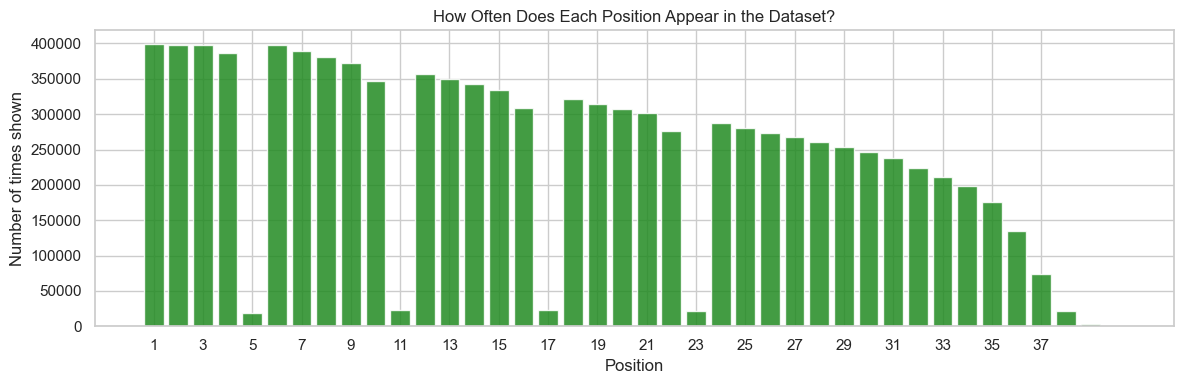

In [8]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

pos_counts = df['position'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(pos_counts.index, pos_counts.values, color='forestgreen', alpha=0.85, edgecolor='white')
ax.set_xlabel('Position')
ax.set_ylabel('Number of times shown')
ax.set_title('How Often Does Each Position Appear in the Dataset?')
ax.set_xticks(range(1, CONFIG["ranking"]["max_position"] + 1, 2))
plt.tight_layout()
plt.show()

Based on the distributions we will assume a fold of 5 items per page, given that the position distribution drops off sharply after that point, and the majority of interactions happen within the first 5 positions.

> Note that max position was picked arbitrarily.

## Naive/Raw CTR by position

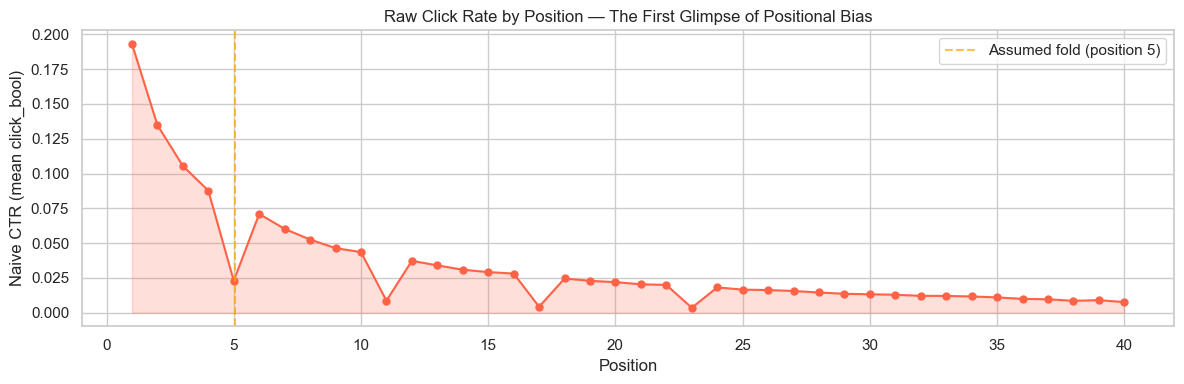

In [9]:
FOLD_POSITION = CONFIG["ranking"]["fold_position"]

ctr_by_pos = df.groupby('position')['click_bool'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ctr_by_pos.index, ctr_by_pos.values, marker='o', color='tomato', markersize=5, linewidth=1.5)
ax.axvline(FOLD_POSITION + 0.05, color='orange', linestyle='--', alpha=0.7,
           label=f'Assumed fold (position {FOLD_POSITION})')
ax.fill_between(ctr_by_pos.index, ctr_by_pos.values, alpha=0.2, color='tomato')
ax.set_xlabel('Position')
ax.set_ylabel('Naive CTR (mean click_bool)')
ax.set_title('Raw Click Rate by Position — The First Glimpse of Positional Bias')
ax.legend()
plt.tight_layout()
plt.show()

CTR drops drastically as position increases, with a steep decline after position 5. This suggests strong position bias, as items in the top positions receive disproportionately more clicks than those further down the list. The fold boundary at position 5 aligns with this drop-off, indicating that items beyond this point are much less likely to be seen and clicked by users.

## CVR by position (booking rate in this case)

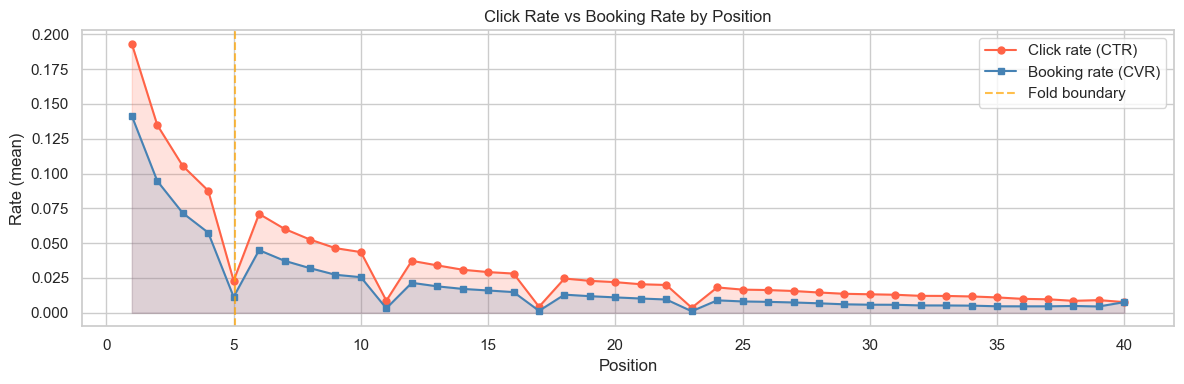

In [10]:
br_by_pos = df.groupby("position")["booking_bool"].mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ctr_by_pos.index, ctr_by_pos.values, marker="o", color="tomato", markersize=5, linewidth=1.5, label="Click rate (CTR)")
ax.fill_between(ctr_by_pos.index, ctr_by_pos.values, color="tomato", alpha=0.18)
ax.plot(br_by_pos.index, br_by_pos.values, marker="s", color="steelblue", markersize=5, linewidth=1.5, label="Booking rate (CVR)")
ax.fill_between(br_by_pos.index, br_by_pos.values, color="steelblue", alpha=0.18)
ax.axvline(FOLD_POSITION + 0.05, color="orange", linestyle="--", alpha=0.7, label="Fold boundary")
ax.set_xlabel("Position")
ax.set_ylabel("Rate (mean)")
ax.set_title("Click Rate vs Booking Rate by Position")
ax.legend()
plt.tight_layout()
plt.show()

Booking rate drops even faster than click rate with position. This makes sense: a user who scrolled deep to find a hotel that matched their needs is more likely to book it (they showed high intent by scrolling), but there are so few of them that the absolute booking rate is low. Positional bias affects not just clicks but every downstream conversion signal. If you train a booking prediction model on raw labels, it will be even more biased than a click model.

## Approximations to UIs

Below, each transformation is not just a preprocessing step.  
It is a **behavioral assumption** about how the user likely experienced the ranking UI.

The idea is simple:

- the same `position` column can mean very different things depending on the interface.
- a user does **not** interact with position 5 in a swipe UI the same way they interact with position 5 in a grid or carousel.
- each function converts the raw log into a dataset that better matches one browsing mechanism.

> Each function lives in `unbiastap.data.datasets` as well as a function `load_expedia` that preprocesses the raw logs. A `train_test_split_by_session` function is also provided to split the data without leaking session information.

#### `get_swipe_next_dataset`

![Swipe-next UI](../img/swipe_next.png)

This is a **swipe-next behavior** view of the data.  
The UI assumption is that the user sees one hotel at a time and must actively move forward to inspect the next one. In that kind of sequential experience, later positions are only reachable if the user passed on the earlier ones.

Order of what it does:

1. Keeps only sessions with at least one click.
2. Identifies the first clicked hotel in each session.
3. Keeps only the hotels shown before that first click, including the clicked one.
4. Marks those remaining rows as `reached = 1`.

This leaves the part of the session that was plausibly reached in a sequential browse flow.

#### `get_carousel_dataset`

![Carousel UI](../img/carousel.png)

This is a **carousel behavior** view of the data.  
The UI assumption is that hotels are shown in small horizontal groups, so position alone is not enough: what matters is both how far the user had to advance and where the hotel appeared inside the visible strip.

Order of what it does:

1. Starts from the original ranked positions.
2. Converts each position into a `carousel_row`.
3. Converts each position into a `slot` within that row.
4. Keeps only the rows up to the chosen carousel depth.

This makes the carousel layout explicit by separating depth from within-row placement.

#### `get_grid_dataset`

![Grid UI](../img/grid.png)

This is a **PLP-style behavior** view of the data.  
Here, PLP means a classic **product listing page** or search results page, like an old Expedia hotel results screen where several hotels are visible at once and the rest require scrolling.

Order of what it does:

1. Starts from the original ranked list.
2. Compares each hotel position against the fold threshold.
3. Flags each row as `above_fold = True/False`.

This creates a simple visibility signal for a classic grid or vertical listing page.